In [ ]:
import marimo as mo

# Physics-Informed SYMBA: GATv2 vs. sequence-only baseline

Predicting squared scattering amplitudes from Feynman diagrams and
unsquared amplitude strings, comparing a GATv2 graph encoder
(`full_model`) against a matched baseline with the graph encoder
removed (`no_gat`).

Set the data paths in the "Data location" cell below before running.

## Parameter count vs. graph encoder availability

The Transformer encoder + decoder stacks alone (4 layers each, d=128,
ffn=512, 8 heads) already total ~2.0M parameters, before the GAT
encoder, physics MLP, or any embedding table is added. If
`torch_geometric` isn't importable, `GATGraphEncoder` falls back to a
small MLP (~9K params) instead of the GATv2 stack (~309K params), and
the forward pass follows the same fallback silently — `full_model`
would then train as `no_gat` in disguise. The assertion below turns
that into a hard failure instead of a silent one.

In [ ]:
# ── Setup / imports ────────────────────────────────────────────────────
import os, re, math, random, pickle, json, copy, warnings, hashlib, sys, subprocess, glob
from collections import OrderedDict, Counter
from pathlib import Path
import itertools

def ensure_pkg(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
        return __import__(import_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
editdistance = ensure_pkg("editdistance")
tqdm_module = ensure_pkg("tqdm")
from tqdm import tqdm
import networkx as nx
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import LambdaLR

try:
    from torch_geometric.data import Data, Batch
    from torch_geometric.nn import GATv2Conv, global_mean_pool
    HAS_PYGEOM = True
    print("PyTorch Geometric: OK  (GATv2Conv ready)")
except ImportError:
    print("PyTorch Geometric not found -- installing torch_geometric...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"])
        from torch_geometric.data import Data, Batch
        from torch_geometric.nn import GATv2Conv, global_mean_pool
        HAS_PYGEOM = True
        print("PyTorch Geometric: OK  (GATv2Conv ready, installed just now)")
    except Exception as e:
        HAS_PYGEOM = False
        Data = Batch = GATv2Conv = global_mean_pool = None
        print(f"PyTorch Geometric: install failed ({e}). "
              "GAT encoder unavailable until this is resolved.")

try:
    import sympy as sp
    HAS_SYMPY = True
    print("SymPy: OK")
except ImportError:
    HAS_SYMPY = False
    sp = None
    print("SymPy: NOT FOUND -- validation disabled")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print(f"Device: {DEVICE}  dtype={DTYPE}")

PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3

SEEDS = [42, 137, 2026]

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEEDS[0])
print("Imports OK")

PyTorch Geometric: OK  (GATv2Conv ready)
SymPy: OK
Device: cuda  dtype=torch.bfloat16
Imports OK


## Vocabulary & tokenizer

In [ ]:
class AmplitudeTokenizer:
    def __init__(self, index_pool_size=1000, special_symbols=None, to_replace=True):
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace
        if special_symbols is None:
            self.special_symbols = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>']
        else:
            self.special_symbols = special_symbols
        self.index_pool = [f'INDEX_{i}' for i in range(index_pool_size)]
        self.pindex_pool = [f'PINDEX_{i}' for i in range(index_pool_size)]
        self.pat_particle = re.compile(r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)')
        self.pat_num123 = re.compile(r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b')

    @staticmethod
    def remove_whitespace(t):
        return re.sub(r'\s+', '', t)

    @staticmethod
    def split_expression(t):
        return re.split(r' ', t)

    def normalize_indices(self, text):
        if not self.to_replace:
            return text
        text = self.remove_whitespace(text)
        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r's_(\d+)', r'MOMENTUM_\1', text)
        text = text.replace('\\\\', '\\').replace('\\', ' \\ ').replace('%', ' % ')
        ms = list(OrderedDict.fromkeys(self.pat_num123.findall(text)))
        it = iter(self.index_pool); mp = {}
        for m in ms:
            try:
                mp[m] = next(it)
            except StopIteration:
                raise RuntimeError('INDEX pool exhausted')
        for o, n in sorted(mp.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(o, n)
        ps = list(OrderedDict.fromkeys(
            m.group('target') for m in sorted(
                self.pat_particle.finditer(text), key=lambda m: m.start())))
        it2 = iter(self.pindex_pool); pp = {}
        for m in ps:
            try:
                pp[m] = next(it2)
            except StopIteration:
                raise RuntimeError('PINDEX pool exhausted')
        for o, n in sorted(pp.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(o, n)
        return text

    def tokenize_amplitude(self, t):
        text = self.normalize_indices(t) if self.to_replace else t
        text = self.remove_whitespace(text)
        text = text.replace('(*)', ' CONJ ').replace('(theta_W)', '_theta_W')
        text = text.replace('\\\\', '\\').replace('\\', ' \\ ').replace('%', ' % ')
        for s in ['/', '+', '-', '*', ',', '^', '}', '(', ')', '=', '[', ']']:
            text = text.replace(s, f' {s} ')
        text = text.replace('_PINDEX', '_ PINDEX').replace('_INDEX', '_ INDEX')
        text = text.replace('reg_prop', ' reg_prop ')
        text = re.sub(r' {2,}', ' ', text).strip()
        return [x for x in self.split_expression(text) if x]

    def tokenize_squared(self, t):
        text = self.normalize_indices(t) if self.to_replace else t
        text = self.remove_whitespace(text).replace('(theta_W)', '_theta_W')
        for s in ['/', '+', '-', '*', ',', '^', '}', '(', ')', '=', '[', ']']:
            text = text.replace(s, f' {s} ')
        text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)
        text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)
        text = text.replace('reg_prop', ' reg_prop ')
        text = re.sub(r' {2,}', ' ', text).strip()
        return [x for x in self.split_expression(text) if x]

class Vocabulary:
    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=None):
        if term_idx is None:
            term_idx = [5, 6]
        tokens = [t for t in list(tokens) if t not in special_symbols]
        self.token_list = special_symbols + tokens
        self.token_to_idx = {t: i for i, t in enumerate(self.token_list)}
        self.idx_to_token = {i: t for t, i in self.token_to_idx.items()}
        self.pad_idx = pad_idx; self.unk_idx = unk_idx
        self.bos_idx = bos_idx; self.eos_idx = eos_idx
        self.sep_idx = sep_idx; self.term_idx = term_idx
        self.special_indices = set(self.token_to_idx[s] for s in special_symbols)

    def encode(self, tokens):
        return [self.token_to_idx.get(t, self.unk_idx) for t in tokens]

    def decode(self, indices, include_special=True):
        if include_special:
            return [self.idx_to_token.get(i, '<UNK>') for i in indices]
        return [self.idx_to_token.get(i, '<UNK>') for i in indices
                if i not in self.special_indices or i == self.sep_idx]

    def __len__(self):
        return len(self.token_list)

    def __getitem__(self, x):
        if isinstance(x, int):
            return self.idx_to_token.get(x, '<UNK>')
        return self.token_to_idx.get(x, self.unk_idx)

print('Vocabulary & Tokenizer defined.')

Vocabulary & Tokenizer defined.


## Raw data parser
Parses `.txt` files with three colon-separated fields per line:
interaction, diagram+amplitude, squared amplitude. If a preprocessed
`processed_data.pkl` exists instead, the loader cell below uses that
directly.

In [ ]:
def parse_raw_txt_file(filepath):
    records = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(' : ')
            if len(parts) < 3:
                continue
            interaction = parts[0].strip()
            mid = ' : '.join(parts[1:-1])
            squared = parts[-1].strip()
            amp_match = re.search(r':\s*(-[\d/]|i\*|[\d/])', mid)
            if amp_match:
                diagram = mid[:amp_match.start()].strip()
                amplitude = mid[amp_match.start():].strip().lstrip(': ').strip()
            else:
                diagram = mid
                amplitude = mid
            records.append({
                'interaction': interaction, 'diagram': diagram,
                'amplitude': amplitude, 'squared': squared,
            })
    return records

def load_and_tokenize_raw(filepaths, tokenizer, is_qcd=False):
    all_records = []
    for fp in filepaths:
        if not os.path.exists(fp):
            print(f'  [SKIP] {fp} not found')
            continue
        recs = parse_raw_txt_file(fp)
        for r in recs:
            r['amp_tokens'] = tokenizer.tokenize_amplitude(r['amplitude'])
            r['sq_tokens'] = tokenizer.tokenize_squared(r['squared'])
            r['is_qcd'] = is_qcd
        all_records.extend(recs)
        print(f'  Loaded {len(recs):4d} records from {os.path.basename(fp)}')
    return all_records

def build_vocabulary(records, min_freq=1):
    special = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>']
    src_counter, tgt_counter = Counter(), Counter()
    for r in records:
        src_counter.update(r['amp_tokens'])
        tgt_counter.update(r['sq_tokens'])
    src_vocab = Vocabulary([t for t, c in src_counter.items() if c >= min_freq], special)
    tgt_vocab = Vocabulary([t for t, c in tgt_counter.items() if c >= min_freq], special)
    return src_vocab, tgt_vocab

def legacy_random_split(records, train_ratio=0.8, val_ratio=0.1, seed=42):
    """Plain random 80/10/10 shuffle split, no topology awareness. Kept as
    a fallback for raw .txt loading; use topology_split() below for the
    train/val/id_test/OOD split used everywhere else in this notebook."""
    rng = random.Random(seed)
    data = records[:]
    rng.shuffle(data)
    n = len(data)
    n_tr = int(n * train_ratio)
    n_va = int(n * val_ratio)
    return data[:n_tr], data[n_tr:n_tr + n_va], data[n_tr + n_va:]

print('Raw data parser defined.')

Raw data parser defined.


## Data location

Downloads `processed_data.pkl` from Google Drive on first run and
caches it locally. Falls back to downloading the raw `.txt` data
folder if the pickle isn't available.

In [ ]:
gdown = ensure_pkg("gdown")
GDRIVE_PKL_FILE_ID = "1gH_0jJcJT71uuxljIvif3yfx_ifC8pyT"
GDRIVE_DATA_FOLDER_ID = "1OX1DnTiUytXJUAbSa0Ib8OJ377HYgWx0"

DATA_DIR = "./data"
RAW_DIR = os.path.join(DATA_DIR, "raw")
PKL_PATH = os.path.join(DATA_DIR, "processed_data.pkl")
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(PKL_PATH):
    print("Downloading processed_data.pkl from Google Drive...")
    gdown.download(id=GDRIVE_PKL_FILE_ID, output=PKL_PATH, quiet=False)
else:
    print(f"Found existing {PKL_PATH}, skipping download.")

if not os.path.exists(PKL_PATH) or os.path.getsize(PKL_PATH) == 0:
    print("processed_data.pkl not available -- downloading the raw data folder instead...")
    os.makedirs(RAW_DIR, exist_ok=True)
    gdown.download_folder(id=GDRIVE_DATA_FOLDER_ID, output=RAW_DIR, quiet=False, use_cookies=False)

DATA_FILES = {
    "qed": sorted(glob.glob(os.path.join(RAW_DIR, "**", "*QED*.txt"), recursive=True)),
    "qcd": sorted(glob.glob(os.path.join(RAW_DIR, "**", "*QCD*.txt"), recursive=True)),
}
GDRIVE_PKL_FILE_ID = "1gH_0jJcJT71uuxljIvif3yfx_ifC8pyT"
GDRIVE_DATA_FOLDER_ID = "1OX1DnTiUytXJUAbSa0Ib8OJ377HYgWx0"

DATA_DIR = "./data"
RAW_DIR = os.path.join(DATA_DIR, "raw")
PKL_PATH = os.path.join(DATA_DIR, "processed_data.pkl")
os.makedirs(DATA_DIR, exist_ok=True)

gdown = ensure_pkg("gdown")

if not os.path.exists(PKL_PATH):
    print("Downloading processed_data.pkl from Google Drive...")
    gdown.download(id=GDRIVE_PKL_FILE_ID, output=PKL_PATH, quiet=False)
else:
    print(f"Found existing {PKL_PATH}, skipping download.")

if not os.path.exists(PKL_PATH) or os.path.getsize(PKL_PATH) == 0:
    print("processed_data.pkl not available -- downloading the raw data folder instead...")
    os.makedirs(RAW_DIR, exist_ok=True)
    gdown.download_folder(id=GDRIVE_DATA_FOLDER_ID, output=RAW_DIR, quiet=False, use_cookies=False)

DATA_FILES = {
    "qed": sorted(glob.glob(os.path.join(RAW_DIR, "**", "*QED*.txt"), recursive=True)),
    "qcd": sorted(glob.glob(os.path.join(RAW_DIR, "**", "*QCD*.txt"), recursive=True)),
}

Found existing ./data/processed_data.pkl, skipping download.
Found existing ./data/processed_data.pkl, skipping download.


In [ ]:
tokenizer = AmplitudeTokenizer()
RAW_DATA = {}

if os.path.exists(PKL_PATH):
    print(f'Loading from pickle: {PKL_PATH}')
    with open(PKL_PATH, 'rb') as _f:
        PKL = pickle.load(_f)
    for _label in ['qed', 'qcd']:
        if _label not in PKL:
            continue
        RAW_DATA[_label.upper()] = {
            'train': PKL[_label]['train'],
            'val': PKL[_label]['val'],
            'test': PKL[_label]['test'],
            'src_vocab': PKL[_label]['src_vocab'],
            'tgt_vocab': PKL[_label]['tgt_vocab'],
        }
        _tr, _va, _te = len(PKL[_label]['train']), len(PKL[_label]['val']), len(PKL[_label]['test'])
        _sv, _tv = len(PKL[_label]['src_vocab']), len(PKL[_label]['tgt_vocab'])
        print(f'  {_label.upper()}: train={_tr}  val={_va}  test={_te}  src_vocab={_sv}  tgt_vocab={_tv}')
else:
    print('Pickle not found. Parsing raw .txt files (or fill in DATA_FILES above)...')
    for _label_key, _filepaths in DATA_FILES.items():
        _label = _label_key.upper()
        _is_qcd = (_label == 'QCD')
        print(f'\n{_label}:')
        _records = load_and_tokenize_raw(_filepaths, tokenizer, is_qcd=_is_qcd)
        if not _records:
            print(f'  [WARNING] No records found for {_label}')
            continue
        _tr, _va, _te = legacy_random_split(_records)
        _src_vocab, _tgt_vocab = build_vocabulary(_tr)
        RAW_DATA[_label] = {
            'train': _tr, 'val': _va, 'test': _te,
            'src_vocab': _src_vocab, 'tgt_vocab': _tgt_vocab,
        }
        print(f'  Loaded: train={len(_tr)}  val={len(_va)}  test={len(_te)}  '
              f'src_vocab={len(_src_vocab)}  tgt_vocab={len(_tgt_vocab)}')

LABELS = list(RAW_DATA.keys())
print(f'\nLabels available: {LABELS}')
if not LABELS:
    print('No data loaded yet -- set PKL_PATH or DATA_FILES above and re-run this cell.')

Loading from pickle: ./data/processed_data.pkl
  QED: train=288  val=36  test=36  src_vocab=97  tgt_vocab=43
  QCD: train=187  val=23  test=24  src_vocab=179  tgt_vocab=67

Labels available: ['QED', 'QCD']


## Physics-aware graph parser

In [ ]:
PARTICLE_PROPS = {
    'e': [0, 0.000511/200, 0.5, 0, -1], 'mu': [1, 0.1057/200, 0.5, 0, -1],
    'tau': [2, 1.777/200, 0.5, 0, -1], 'nu': [3, 0.0, 0.5, 0, 0],
    'u': [4, 0.0022/200, 0.5, 3, 2], 'd': [5, 0.0047/200, 0.5, 3, -1],
    's': [6, 0.096/200, 0.5, 3, -1], 'c': [7, 1.27/200, 0.5, 3, 2],
    'b': [8, 4.18/200, 0.5, 3, -1], 't': [9, 173.0/200, 0.5, 3, 2],
    'tt': [9, 173.0/200, 0.5, 3, 2], 'A': [10, 0.0, 1.0, 0, 0],
    'G': [11, 0.0, 1.0, 8, 0], 'W': [12, 80.4/200, 1.0, 0, 1],
    'Z': [13, 91.2/200, 1.0, 0, 0], 'H': [14, 125.0/200, 0.0, 0, 0],
}
UNKNOWN_PROPS = [15, 0.0, 0.0, 0, 0]
NODE_FEAT_DIM = 5
EDGE_FEAT_DIM = 5
GLOBAL_FEAT_DIM = 7

QCD_COLOR_FACTORS = {
    (2, False): 4/9, (1, True): 1/6, (0, True): 9.0, (2, True): 16/27,
}
COLOR_FACTORS = {
    ('q', 'q', 'q', 'q'): 4/9, ('q', 'qbar', 'q', 'qbar'): 4/9,
    ('q', 'qbar', 'g', 'g'): 16/9, ('g', 'g', 'g', 'g'): 9,
    ('q', 'g', 'q', 'g'): -1/6,
}

def particle_features(pname):
    return PARTICLE_PROPS.get(pname.lower().strip().rstrip('*'), UNKNOWN_PROPS)

def extract_color_factor(diagram_str, is_qcd=False):
    if not is_qcd:
        return 1.0
    cf_match = re.search(r'^(-?\d+/\d+|\d+)', diagram_str.strip())
    if cf_match:
        try:
            return float(eval(cf_match.group(0)))
        except Exception:
            pass
    return 1.0

_vertex_pattern = re.compile(
    r'Vertex\s+(V_\d+):(\w+)\(X_\d+\),\s*(?:AntiPart\s+)?(\w+)\(X_\d+\),\s*'
    r'(?:OffShell\s+)?(\w+)'
)

def parse_diagram_to_graph(diagram_str, is_qcd=False):
    vertices = _vertex_pattern.findall(diagram_str)
    if not vertices:
        nf = torch.zeros(2, NODE_FEAT_DIM)
        ei = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)
        ef = torch.zeros(2, EDGE_FEAT_DIM)
        gf = torch.tensor([0, 0, 1, 0, 1, int(is_qcd), 1.0], dtype=torch.float)
        return nf, ei, ef, gf
    node_features = []
    offshell_particles = []
    for vid, p_in, p_out, offshell in vertices:
        node_features.append(particle_features(p_in))
        offshell_particles.append(offshell)
    n = len(node_features)
    edge_index, edge_features = [], []
    for i in range(n):
        j = (i + 1) % n
        ef_i = particle_features(offshell_particles[i])
        edge_index.append([i, j]); edge_index.append([j, i])
        edge_features.append(ef_i); edge_features.append(ef_i)
    for i in range(n):
        edge_index.append([i, i])
        edge_features.append(node_features[i])
    nf = torch.tensor(node_features, dtype=torch.float)
    ei = torch.tensor(edge_index, dtype=torch.long).T
    ef = torch.tensor(edge_features, dtype=torch.float)
    n_vertices = float(n)
    n_propagators = float(len(offshell_particles))
    n_fermion_lines = sum(
        1 for p in offshell_particles
        if p.lower().rstrip('*') in ['e', 'mu', 'tau', 'u', 'd', 's', 'c', 'b', 't']
    )
    has_gluon = float(any(p.lower() in ['g', 'G'] for p in offshell_particles))
    coupling_order = float(n)
    color_factor = 4/9 if is_qcd else 1.0  # TODO: use extract_color_factor(diagram_str, is_qcd) instead of this constant
    gf = torch.tensor(
        [n_vertices, n_propagators, n_fermion_lines, has_gluon,
         coupling_order, float(is_qcd), color_factor], dtype=torch.float
    )
    return nf, ei, ef, gf

print('Graph parser defined.')

Graph parser defined.


## Topology split

Two-vertex diagrams (`n_vertices==2`, the simplest tree topologies)
form the in-distribution pool, split 80/10/10 into train/val/test.
Multi-propagator diagrams (`n_vertices>=3`) form the held-out pool,
used only for the final out-of-distribution comparison. A
Weisfeiler-Lehman canonical topology ID plus a crossing-symmetry
grouping is used to deduplicate and to check for leakage within the
in-distribution pool before the 80/10/10 draw.

In [ ]:
def canonical_topology_id(diagram_str, is_qcd=False, wl_iterations=3):
    """3-round Weisfeiler-Lehman canonical hash over the parsed graph,
    excluding the connectivity-completion self-loops (parse_diagram_to_graph
    appends one self-loop per node purely for GNN connectivity, not physics)."""
    nf, ei, ef, gf = parse_diagram_to_graph(diagram_str, is_qcd=is_qcd)
    n = nf.shape[0]
    G = nx.Graph()
    for i in range(n):
        feat = tuple(round(float(x), 4) for x in nf[i].tolist())
        G.add_node(i, label=str(feat))
    ei_list = ei.T.tolist()
    for a, b in ei_list:
        if a == b:
            continue  # exclude self-loops from the topology hash
        G.add_edge(a, b)
    if G.number_of_nodes() == 0:
        return "empty"
    return nx.weisfeiler_lehman_graph_hash(
        G, node_attr="label", iterations=wl_iterations
    )

def crossing_superclass_id(diagram_str, is_qcd=False):
    """Species-only skeleton hash (directionality stripped, particle/antiparticle
    merged) -- diagrams sharing this id are crossing-symmetric partners of the
    same physical process and must never be split across train/val/ID-test."""
    nf, ei, ef, gf = parse_diagram_to_graph(diagram_str, is_qcd=is_qcd)
    n = nf.shape[0]
    G = nx.Graph()
    for i in range(n):
        species = int(round(float(nf[i][0].item())))  # particle_type_id, direction-agnostic
        G.add_node(i, label=str(species))
    ei_list = ei.T.tolist()
    for a, b in ei_list:
        if a == b:
            continue
        G.add_edge(a, b)
    if G.number_of_nodes() == 0:
        return "empty"
    return nx.weisfeiler_lehman_graph_hash(G, node_attr="label", iterations=2)

def topology_split(records, is_qcd=False, train_ratio=0.8, val_ratio=0.1, seed=42):
    """Returns (train, val, id_test, ood_test). Raises AssertionError if any
    crossing-superclass leaks across train/val/id_test (checked, not assumed)."""
    id_pool, ood_pool = [], []
    for r in records:
        diag = r.get('diagram', '')
        nf, ei, ef, gf = parse_diagram_to_graph(diag, is_qcd=is_qcd)
        n_vertices = int(round(float(gf[0].item())))
        r = dict(r)
        r['_n_vertices'] = n_vertices
        r['_superclass'] = crossing_superclass_id(diag, is_qcd=is_qcd)
        r['_topo_id'] = canonical_topology_id(diag, is_qcd=is_qcd)
        (id_pool if n_vertices == 2 else ood_pool).append(r)

    # dedupe exact duplicates within each pool (same canonical id, keep first)
    def dedupe(pool):
        seen = set(); out = []
        for r in pool:
            if r['_topo_id'] in seen:
                continue
            seen.add(r['_topo_id']); out.append(r)
        return out
    id_pool = dedupe(id_pool)

    rng = random.Random(seed)
    superclasses = sorted(set(r['_superclass'] for r in id_pool))
    rng.shuffle(superclasses)
    n_sc = len(superclasses)
    n_tr_sc = int(n_sc * train_ratio)
    n_va_sc = int(n_sc * val_ratio)
    tr_sc = set(superclasses[:n_tr_sc])
    va_sc = set(superclasses[n_tr_sc:n_tr_sc + n_va_sc])
    te_sc = set(superclasses[n_tr_sc + n_va_sc:])

    train = [r for r in id_pool if r['_superclass'] in tr_sc]
    val = [r for r in id_pool if r['_superclass'] in va_sc]
    id_test = [r for r in id_pool if r['_superclass'] in te_sc]

    # fail loudly rather than silently ship a leaking split
    assert tr_sc.isdisjoint(va_sc), "train/val superclass leakage"
    assert tr_sc.isdisjoint(te_sc), "train/id_test superclass leakage"
    assert va_sc.isdisjoint(te_sc), "val/id_test superclass leakage"
    id_topo_ids = set(r['_topo_id'] for r in id_pool)
    ood_topo_ids = set(r['_topo_id'] for r in ood_pool)
    assert id_topo_ids.isdisjoint(ood_topo_ids), (
        "ID/OOD canonical-topology overlap -- should be structurally impossible "
        "from the vertex-count criterion alone; investigate if this fires"
    )

    return train, val, id_test, ood_pool

print('Topology canonicalization + split defined.')

Topology canonicalization + split defined.


## Dataset & DataLoader

In [ ]:
def get_max_lens(records, pct=97, cap=512):
    amp_lens = [len(r.get('amp_tokens', [])) for r in records]
    sq_lens = [len(r.get('sq_tokens', [])) for r in records]
    src_max = min(int(np.percentile(amp_lens, pct)) + 4, cap) if amp_lens else cap
    tgt_max = min(int(np.percentile(sq_lens, pct)) + 4, cap) if sq_lens else cap
    return src_max, tgt_max

def recode_records(records, src_vocab, tgt_vocab, src_max, tgt_max, is_qcd=False):
    rows = []
    for r in records:
        amp_toks = list(r.get('amp_tokens', []))
        sq_toks = list(r.get('sq_tokens', []))
        amp_ids = [BOS_IDX] + src_vocab.encode(amp_toks)[:src_max-2] + [EOS_IDX]
        sq_ids = [BOS_IDX] + tgt_vocab.encode(sq_toks)[:tgt_max-2] + [EOS_IDX]
        diag_str = r.get('diagram', '')
        nf, ei, ef, gf = parse_diagram_to_graph(diag_str, is_qcd=is_qcd)
        rows.append({
            'amp_ids': amp_ids, 'sq_ids': sq_ids,
            'amp_tokens': amp_toks, 'sq_tokens': sq_toks,
            'node_feat': nf, 'edge_index': ei, 'edge_feat': ef, 'global_feat': gf,
            'diagram': diag_str, 'squared': r.get('squared', ''), 'is_qcd': is_qcd,
        })
    return rows

class PhysicsDataset(Dataset):
    def __init__(self, rows, src_max, tgt_max):
        self.rows = rows
        self.sm, self.tm = src_max, tgt_max

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        src = torch.tensor(r['amp_ids'][:self.sm], dtype=torch.long)
        tgt = torch.tensor(r['sq_ids'][:self.tm], dtype=torch.long)
        return {
            'src': src, 'tgt': tgt, 'node_feat': r['node_feat'],
            'edge_index': r['edge_index'], 'edge_feat': r['edge_feat'],
            'global_feat': r['global_feat'], 'sq_tokens': r['sq_tokens'],
            'squared': r['squared'], 'is_qcd': r['is_qcd'],
        }

def collate_physics(batch):
    src = pad_sequence([b['src'] for b in batch], padding_value=PAD_IDX, batch_first=True)
    tgt = pad_sequence([b['tgt'] for b in batch], padding_value=PAD_IDX, batch_first=True)
    gf = torch.stack([b['global_feat'] for b in batch])
    if HAS_PYGEOM:
        graphs = [Data(x=b['node_feat'], edge_index=b['edge_index'], edge_attr=b['edge_feat'])
                  for b in batch]
        graph_batch = Batch.from_data_list(graphs)
    else:
        graph_batch = None
    meta = {
        'sq_tokens': [b['sq_tokens'] for b in batch],
        'squared': [b['squared'] for b in batch],
        'is_qcd': [b['is_qcd'] for b in batch],
    }
    return src, tgt, graph_batch, gf, meta

print('Dataset/DataLoader classes defined.')

Dataset/DataLoader classes defined.


## Edge-scramble ablation

Typed configuration-model double-edge-swap: swaps only happen between
edges of the same role type (same particle-species pair, so a
photon-propagator edge only swaps with another photon-propagator
edge), which preserves each node's degree and its vertex valence-type
composition -- so scrambling can't produce a physically-impossible
vertex (e.g. 3 fermion legs, 0 photon legs). Node features, global
features, and the edge-attribute multiset are left untouched; only
the wiring is scrambled. Runs inside the collate function, seeded
from `(seed, epoch, batch_idx)` so it stays reproducible.

In [ ]:
def scramble_edges_typed(node_feat, edge_index, edge_feat, rng, q=10):
    """Degree- and valence-type-preserving double-edge-swap over the physical
    (non-self-loop) propagator edges. node_feat / edge_feat are untouched;
    only edge_index connectivity + the assignment of edge_feat rows changes."""
    ei = edge_index.T.tolist()
    ef = edge_feat.clone()
    # physical edges are every entry that isn't a self-loop (a==b);
    # they come in symmetric (i,j)/(j,i) pairs from parse_diagram_to_graph
    phys_idx = [k for k, (a, b) in enumerate(ei) if a != b]
    if len(phys_idx) < 4:
        return edge_index, edge_feat  # too small to meaningfully scramble

    def role_type(k):
        a, b = ei[k]
        # role type = the (rounded) particle-type id pair riding this edge slot
        return (round(float(node_feat[a][0].item()), 2), round(float(node_feat[b][0].item()), 2))

    by_role = {}
    for k in phys_idx:
        by_role.setdefault(role_type(k), []).append(k)

    n_swaps = q * len(phys_idx)
    for _ in range(n_swaps):
        candidates = [g for g in by_role.values() if len(g) >= 2]
        if not candidates:
            break
        group = rng.choice(candidates)
        k1, k2 = rng.sample(group, 2)
        a1, b1 = ei[k1]
        a2, b2 = ei[k2]
        if a1 == a2 or b1 == b2:
            continue
        ei[k1] = [a1, b2]
        ei[k2] = [a2, b1]

    new_edge_index = torch.tensor(ei, dtype=torch.long).T
    # reassign the ORIGINAL multiset of edge attribute vectors via a uniform
    # random permutation restricted to the physical-edge slots, so the
    # edge-attribute marginal distribution is exactly preserved
    perm = phys_idx[:]
    rng.shuffle(perm)
    new_ef = ef.clone()
    for src_k, dst_k in zip(phys_idx, perm):
        new_ef[dst_k] = ef[src_k]
    return new_edge_index, new_ef

def make_collate_physics_scrambled(seed):
    """Returns a collate_fn closed over `seed`. Call .next_epoch() at the
    end of each epoch so the scramble stays reproducible across runs."""
    _batch_counter = {"epoch": 0, "batch": 0}

    def collate_physics_scrambled(batch):
        seed_int = (seed * 1_000_003 + _batch_counter["epoch"]) * 1_000_003 + _batch_counter["batch"]
        rng = random.Random(seed_int)
        _batch_counter["batch"] += 1

        src = pad_sequence([b['src'] for b in batch], padding_value=PAD_IDX, batch_first=True)
        tgt = pad_sequence([b['tgt'] for b in batch], padding_value=PAD_IDX, batch_first=True)
        gf = torch.stack([b['global_feat'] for b in batch])
        if HAS_PYGEOM:
            graphs = []
            for b in batch:
                new_ei, new_ef = scramble_edges_typed(
                    b['node_feat'], b['edge_index'], b['edge_feat'], rng
                )
                graphs.append(Data(x=b['node_feat'], edge_index=new_ei, edge_attr=new_ef))
            graph_batch = Batch.from_data_list(graphs)
        else:
            graph_batch = None
        meta = {
            'sq_tokens': [b['sq_tokens'] for b in batch],
            'squared': [b['squared'] for b in batch],
            'is_qcd': [b['is_qcd'] for b in batch],
        }
        return src, tgt, graph_batch, gf, meta

    def next_epoch():
        _batch_counter["epoch"] += 1
        _batch_counter["batch"] = 0

    collate_physics_scrambled.next_epoch = next_epoch
    return collate_physics_scrambled

print('Edge-scramble ablation defined.')

Edge-scramble ablation defined.


## Build split datasets (ID: train/val/id_test, OOD: held-out multi-propagator)

In [ ]:
DATASETS = {}
OOD_DATASETS = {}

for _label in LABELS:
    _sv = RAW_DATA[_label]['src_vocab']
    _tv = RAW_DATA[_label]['tgt_vocab']
    _is_qcd = (_label == 'QCD')

    _all_records = RAW_DATA[_label]['train'] + RAW_DATA[_label]['val'] + RAW_DATA[_label]['test']
    _train, _val, _id_test, _ood_test = topology_split(_all_records, is_qcd=_is_qcd)

    _src_max, _tgt_max = get_max_lens(_train)
    _tr_rows = recode_records(_train, _sv, _tv, _src_max, _tgt_max, _is_qcd)
    _va_rows = recode_records(_val, _sv, _tv, _src_max, _tgt_max, _is_qcd)
    _te_rows = recode_records(_id_test, _sv, _tv, _src_max, _tgt_max, _is_qcd)
    _ood_rows = recode_records(_ood_test, _sv, _tv, _src_max, _tgt_max, _is_qcd)

    DATASETS[_label] = {
        'train': PhysicsDataset(_tr_rows, _src_max, _tgt_max),
        'val': PhysicsDataset(_va_rows, _src_max, _tgt_max),
        'test': PhysicsDataset(_te_rows, _src_max, _tgt_max),   # ID test (sealed)
        'src_vocab': _sv, 'tgt_vocab': _tv,
        'src_max': _src_max, 'tgt_max': _tgt_max,
    }
    OOD_DATASETS[_label] = PhysicsDataset(_ood_rows, _src_max, _tgt_max)  # OOD held-out (sealed)

    print(f'{_label}: ID train={len(_tr_rows)}  val={len(_va_rows)}  id_test={len(_te_rows)}  '
          f'OOD_held_out={len(_ood_rows)}  src_max={_src_max}  tgt_max={_tgt_max}  '
          f'src_vocab={len(_sv)}  tgt_vocab={len(_tv)}')

print('Split datasets built.')

QED: ID train=36  val=4  id_test=5  OOD_held_out=180  src_max=182  tgt_max=128  src_vocab=97  tgt_vocab=43
QCD: ID train=22  val=2  id_test=4  OOD_held_out=115  src_max=512  tgt_max=512  src_vocab=179  tgt_vocab=67
Split datasets built.


## SymPy validation layer

`check_coupling_power()` (defined later, used for the `coupling_ok`
metric) does a literal token-scan for a `coupling, '^', power` triple
and does not algebraically normalize `e^2 * e^2` into `e^4`. The check
inside `validate_squared_amplitude()` below instead uses
`sp.Poly(expr, coupling).degree()` on the parsed SymPy expression,
which handles that case correctly. `sympy_valid` and `coupling_ok`
can therefore disagree on the same prediction.

In [ ]:
if HAS_SYMPY:
    _s12, _s13, _s14, _s23, _s24, _s34 = sp.symbols('s_12 s_13 s_14 s_23 s_24 s_34', real=True)
    _m_e, _m_mu, _m_tau = sp.symbols('m_e m_mu m_tau', positive=True)
    _m_u, _m_d, _m_s = sp.symbols('m_u m_d m_s', positive=True)
    _m_c, _m_b, _m_t = sp.symbols('m_c m_b m_t', positive=True)
    _m_tt = sp.symbols('m_tt', positive=True)
    _e, _g = sp.symbols('e g', positive=True)
    _reg_prop = sp.symbols('reg_prop', positive=True)

    ALLOWED_SYMBOLS = {
        _s12, _s13, _s14, _s23, _s24, _s34, _m_e, _m_mu, _m_tau, _m_u, _m_d,
        _m_s, _m_c, _m_b, _m_t, _m_tt, _e, _g, _reg_prop,
    }
    _LOCALS_MAP = {
        's_12': _s12, 's_13': _s13, 's_14': _s14, 's_23': _s23, 's_24': _s24, 's_34': _s34,
        'm_e': _m_e, 'm_mu': _m_mu, 'm_tau': _m_tau, 'm_u': _m_u, 'm_d': _m_d, 'm_s': _m_s,
        'm_c': _m_c, 'm_b': _m_b, 'm_t': _m_t, 'm_tt': _m_tt,
        'e': _e, 'g': _g, 'reg_prop': _reg_prop, 'i': 1,
        **{f'idx{i}': sp.Symbol(f'idx{i}', positive=True) for i in range(500)},
        **{f'pidx{i}': sp.Symbol(f'pidx{i}', positive=True) for i in range(500)},
        **{f'mom{i}': sp.Symbol(f'mom{i}', positive=True) for i in range(50)},
    }
    _SUBS_TEMPLATE = {
        _s12: 10.0, _s34: 10.0, _s13: -3.0, _s24: -3.0, _s14: -3.0, _s23: -3.0,
        _m_e: 1.0, _m_mu: 1.0, _m_tau: 1.0, _m_u: 1.0, _m_d: 1.0, _m_s: 1.0,
        _m_c: 1.0, _m_b: 1.0, _m_t: 1.0, _m_tt: 1.0, _e: 0.303, _g: 1.0, _reg_prop: 0.001,
    }
    COUPLING_SYM = {'e': _e, 'g': _g}
else:
    ALLOWED_SYMBOLS, _LOCALS_MAP, _SUBS_TEMPLATE, COUPLING_SYM = set(), {}, {}, {}

def tokens_to_sympy_string(tokens):
    import re as _re
    text = ' '.join(tokens)
    for s in ['<BOS>', '<EOS>', '<PAD>', '<UNK>', '<SEP>', '<TERM0>', '<TERM1>']:
        text = text.replace(s, '')
    for i in range(500):
        text = text.replace(f'PINDEX_{i}', f'pidx{i}')
        text = text.replace(f'INDEX_{i}', f'idx{i}')
    text = _re.sub(r'MOMENTUM_(\d+)', r'mom\1', text)
    text = _re.sub(r'\s+', '', text)
    text = text.replace('^', '**')
    return text.strip()

def validate_squared_amplitude(token_list, global_feat_vec, is_qcd=False):
    if not HAS_SYMPY:
        return {'valid': True, 'violations': [], 'n_violations': 0, 'penalty': 0.0}
    violations = []
    expr_str = tokens_to_sympy_string(token_list)
    if not expr_str:
        return {'valid': False, 'violations': ['empty_expression'], 'n_violations': 1, 'penalty': 1.0}
    try:
        expr = sp.sympify(expr_str, locals=_LOCALS_MAP)
    except Exception as ex:
        return {'valid': False, 'violations': [f'parse_error: {ex}'], 'n_violations': 1, 'penalty': 1.0}

    idx_syms = {v for k, v in _LOCALS_MAP.items() if k.startswith(('idx', 'pidx', 'mom'))}
    forbidden = expr.free_symbols - ALLOWED_SYMBOLS - idx_syms
    if forbidden:
        violations.append(f'forbidden_symbols={[str(s) for s in forbidden]}')

    if global_feat_vec is not None:
        n_verts = int(float(global_feat_vec[0]))
        expected_pow = 2 * n_verts
        coupling = COUPLING_SYM['g'] if is_qcd else COUPLING_SYM['e']
        try:
            actual_pow = sp.Poly(expr, coupling).degree() if expr.has(coupling) else 0
            if actual_pow != expected_pow:
                violations.append(f'coupling_power={actual_pow} (expected {expected_pow})')
        except Exception:
            pass

    try:
        val = complex(expr.subs(_SUBS_TEMPLATE))
        if abs(val.imag) > 1e-4:
            violations.append(f'imaginary_part={val.imag:.3e}')
    except Exception:
        violations.append('kinematic_eval_error')

    n_v = len(violations)
    return {'valid': n_v == 0, 'violations': violations, 'n_violations': n_v, 'penalty': min(1.0, n_v / 3.0)}

print('SymPy validation layer defined.')

SymPy validation layer defined.


## Model configuration

In [ ]:
CFG = {
    'dim': 128, 'num_heads': 8, 'head_dim': 16, 'ffn_dim': 512,
    'num_enc_layers': 4, 'num_dec_layers': 4,
    'gnn_hidden': 64, 'gnn_layers': 3, 'gnn_heads': 4, 'gnn_dropout': 0.1,
    'node_feat_dim': NODE_FEAT_DIM, 'edge_feat_dim': EDGE_FEAT_DIM, 'global_feat_dim': GLOBAL_FEAT_DIM,
    'max_seq_len': 600, 'use_rope': True, 'init_std': 0.02,   # use_rope is not read anywhere below (no RoPE in the encoder/decoder)
    'dropout': 0.10, 'label_smoothing': 0.05,
    'batch_size': 8, 'grad_accum': 4, 'epochs': 100, 'lr': 3e-4, 'end_lr': 1e-6,
    'weight_decay': 1e-4, 'warmup_ratio': 0.10, 'clip_grad': 1.0,
}
CKPT_DIR = './ckpt_gat_symba'
EVAL_DIR = './eval_gat_symba'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)
print('Config ready.')

Config ready.


## Model classes

In [ ]:
class GATGraphEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.use_pygeom = HAS_PYGEOM
        if cfg.get('use_gat', True):
            assert HAS_PYGEOM, (
                "use_gat=True but torch_geometric is not importable. "
                "Install it (pip install torch-geometric) rather than "
                "silently falling back to the small MLP path."
            )
        in_dim, h_dim, out_dim = cfg['node_feat_dim'], cfg['gnn_hidden'], cfg['dim']
        heads, edge_dim, dropout = cfg['gnn_heads'], cfg['edge_feat_dim'], cfg['gnn_dropout']
        self.input_proj = nn.Linear(in_dim, h_dim)
        self.edge_proj = nn.Linear(edge_dim, h_dim)
        if self.use_pygeom:
            self.gat1 = GATv2Conv(h_dim, h_dim, heads=heads, concat=True, dropout=dropout,
                                   edge_dim=h_dim, add_self_loops=True)
            self.norm1 = nn.LayerNorm(h_dim * heads)
            self.gat2 = GATv2Conv(h_dim * heads, h_dim, heads=heads, concat=True, dropout=dropout,
                                   edge_dim=h_dim, add_self_loops=True)
            self.norm2 = nn.LayerNorm(h_dim * heads)
            self.gat3 = GATv2Conv(h_dim * heads, out_dim, heads=1, concat=False, dropout=dropout,
                                   edge_dim=h_dim, add_self_loops=True)
            self.norm3 = nn.LayerNorm(out_dim)
        else:
            self.fallback = nn.Sequential(
                nn.Linear(cfg['global_feat_dim'] + in_dim, h_dim), nn.SiLU(),
                nn.LayerNorm(h_dim), nn.Linear(h_dim, out_dim),
            )
        self.global_proj = nn.Linear(cfg['global_feat_dim'], out_dim)
        self.fusion_norm = nn.LayerNorm(out_dim)
        self.fusion_gate = nn.Sequential(nn.Linear(out_dim * 2, out_dim), nn.Sigmoid())
        self.act = nn.SiLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, graph_batch, global_feats):
        g_proj = self.global_proj(global_feats)
        if self.use_pygeom and graph_batch is not None:
            x = self.input_proj(graph_batch.x.to(global_feats.device))
            ei = graph_batch.edge_index.to(global_feats.device)
            ea = self.edge_proj(graph_batch.edge_attr.to(global_feats.device))
            bv = graph_batch.batch.to(global_feats.device)
            x = self.act(self.norm1(self.gat1(x, ei, edge_attr=ea))); x = self.dropout(x)
            x = self.act(self.norm2(self.gat2(x, ei, edge_attr=ea))); x = self.dropout(x)
            x = self.norm3(self.gat3(x, ei, edge_attr=ea))
            x_pooled = global_mean_pool(x, bv)
        else:
            x_pooled = g_proj
        gate = self.fusion_gate(torch.cat([x_pooled, g_proj], dim=-1))
        out = self.fusion_norm(gate * x_pooled + (1 - gate) * g_proj)
        return out

print('GATGraphEncoder defined.')

GATGraphEncoder defined.


In [ ]:
class AmplitudeTransformerEncoder(nn.Module):
    def __init__(self, cfg, vocab_size):
        super().__init__()
        d, n_heads, ffn_dim = cfg['dim'], cfg['num_heads'], cfg['ffn_dim']
        dropout, n_layers, max_seq = cfg['dropout'], cfg['num_enc_layers'], cfg['max_seq_len']
        self.embed = nn.Embedding(vocab_size, d, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_seq, d)
        nn.init.normal_(self.embed.weight, std=cfg['init_std'])
        nn.init.normal_(self.pos_emb.weight, std=cfg['init_std'])
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=n_heads, dim_feedforward=ffn_dim, dropout=dropout,
            batch_first=True, norm_first=True, activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.out_norm = nn.LayerNorm(d)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_key_padding_mask=None):
        B, S = src.shape
        positions = torch.arange(S, device=src.device).unsqueeze(0).expand(B, -1)
        x = self.dropout(self.embed(src) + self.pos_emb(positions))
        x = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        return self.out_norm(x)

print('AmplitudeTransformerEncoder defined.')

AmplitudeTransformerEncoder defined.


In [ ]:
class SquaredAmplitudeDecoder(nn.Module):
    def __init__(self, cfg, tgt_vocab_size):
        super().__init__()
        d, n_heads, ffn_dim = cfg['dim'], cfg['num_heads'], cfg['ffn_dim']
        dropout, n_layers, max_seq = cfg['dropout'], cfg['num_dec_layers'], cfg['max_seq_len']
        self.embed = nn.Embedding(tgt_vocab_size, d, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_seq, d)
        nn.init.normal_(self.embed.weight, std=cfg['init_std'])
        nn.init.normal_(self.pos_emb.weight, std=cfg['init_std'])
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d, nhead=n_heads, dim_feedforward=ffn_dim, dropout=dropout,
            batch_first=True, norm_first=True, activation='gelu',
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.out_norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, tgt_vocab_size, bias=False)  # weight-tied to self.embed below
        self.head.weight = self.embed.weight
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        B, T = tgt.shape
        positions = torch.arange(T, device=tgt.device).unsqueeze(0).expand(B, -1)
        x = self.dropout(self.embed(tgt) + self.pos_emb(positions))
        causal_mask = torch.triu(torch.ones(T, T, device=tgt.device), diagonal=1).bool()
        out = self.decoder(tgt=x, memory=memory, tgt_mask=causal_mask,
                            tgt_key_padding_mask=tgt_key_padding_mask,
                            memory_key_padding_mask=memory_key_padding_mask)
        return self.head(self.out_norm(out))

print('SquaredAmplitudeDecoder defined.')

SquaredAmplitudeDecoder defined.


## Full model

`use_gat=False` (the `no_gat` ablation) skips creating `self.gat_encoder`
and its side-token in `build_memory()` -- nothing replaces the removed
capacity, so `no_gat` is `full_model` minus the GAT branch (see the
parameter-count cell for the exact gap).

`self.fallback_emb` is created unconditionally regardless of
`use_amp_encoder`, so every variant carries an extra `V_src*128`-sized
embedding table that the forward pass never touches when
`use_amp_encoder=True` (the default in all ablation configs below).

In [ ]:
class PhysicsInformedSYMBA(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        d = cfg['dim']
        if cfg.get('use_gat', True):
            self.gat_encoder = GATGraphEncoder(cfg)
        if cfg.get('use_amp_encoder', True):
            self.amp_encoder = AmplitudeTransformerEncoder(cfg, cfg['src_vocab_size'])
        if cfg.get('use_physics_feats', True):
            self.physics_mlp = nn.Sequential(
                nn.Linear(cfg['global_feat_dim'], d), nn.SiLU(),
                nn.LayerNorm(d), nn.Linear(d, d),
            )
        self.fallback_emb = nn.Sequential(   # always created -- see markdown above
            nn.Embedding(cfg['src_vocab_size'], d, padding_idx=PAD_IDX), nn.LayerNorm(d),
        )
        self.decoder = SquaredAmplitudeDecoder(cfg, cfg['tgt_vocab_size'])

    def build_memory(self, src, graph_batch, global_feats, src_pad_mask):
        B = src.shape[0]
        side_tokens = []
        if self.cfg.get('use_gat', True):
            gat_emb = self.gat_encoder(graph_batch, global_feats)
            side_tokens.append(gat_emb.unsqueeze(1))
        if self.cfg.get('use_physics_feats', True):
            phys_emb = self.physics_mlp(global_feats)
            side_tokens.append(phys_emb.unsqueeze(1))
        if self.cfg.get('use_amp_encoder', True):
            src_padding_mask = (src == PAD_IDX)
            amp_enc = self.amp_encoder(src, src_key_padding_mask=src_padding_mask)
        else:
            amp_enc = self.fallback_emb[0](src)
            amp_enc = self.fallback_emb[1](amp_enc)
        if side_tokens:
            side = torch.cat(side_tokens, dim=1)
            memory = torch.cat([side, amp_enc], dim=1)
            side_mask = torch.ones(B, side.shape[1], dtype=torch.bool, device=src.device)
        else:
            memory = amp_enc
            side_mask = torch.zeros(B, 0, dtype=torch.bool, device=src.device)
        amp_real_mask = (src != PAD_IDX)
        mem_real_mask = torch.cat([side_mask, amp_real_mask], dim=1)
        return memory, mem_real_mask

    def forward(self, src, tgt, graph_batch, global_feats):
        src_pad_mask = (src == PAD_IDX)
        tgt_pad_mask = (tgt == PAD_IDX)
        memory, mem_real_mask = self.build_memory(src, graph_batch, global_feats, src_pad_mask)
        return self.decoder(tgt=tgt, memory=memory, tgt_key_padding_mask=tgt_pad_mask,
                             memory_key_padding_mask=~mem_real_mask)

    @torch.no_grad()
    def greedy_decode(self, src, graph_batch, global_feats, max_len=200):
        self.eval()
        B = src.shape[0]
        src_pad_mask = (src == PAD_IDX)
        memory, mem_real_mask = self.build_memory(src, graph_batch, global_feats, src_pad_mask)
        ys = torch.full((B, 1), 2, dtype=torch.long, device=src.device)  # BOS_IDX=2
        done = torch.zeros(B, dtype=torch.bool, device=src.device)
        for _ in range(max_len - 1):
            logits = self.decoder(tgt=ys, memory=memory, memory_key_padding_mask=~mem_real_mask)
            next_tok = logits[:, -1, :].argmax(-1)
            done |= (next_tok == 3)  # EOS_IDX=3
            ys = torch.cat([ys, next_tok.unsqueeze(1)], dim=1)
            if done.all():
                break
        return ys

print('PhysicsInformedSYMBA defined.')

PhysicsInformedSYMBA defined.


## Parameter count

Builds real models for each ablation and prints
`sum(p.numel() for p in model.parameters())` directly, rather than
estimating it.

In [ ]:
def build_model(label, ablation_cfg=None):
    sv = DATASETS[label]['src_vocab']
    tv = DATASETS[label]['tgt_vocab']
    cfg = copy.deepcopy(CFG)
    cfg['src_vocab_size'] = len(sv)
    cfg['tgt_vocab_size'] = len(tv)
    if ablation_cfg:
        cfg.update(ablation_cfg)
    model = PhysicsInformedSYMBA(cfg)
    return model, cfg

FULL_MODEL_FLAGS = {'use_gat': True, 'use_physics_feats': True, 'use_amp_encoder': True}
ABLATION_CONFIGS = [
    ('full_model', {**FULL_MODEL_FLAGS}),
    ('no_gat', {**FULL_MODEL_FLAGS, 'use_gat': False}),
    ('no_phys_feats', {**FULL_MODEL_FLAGS, 'use_physics_feats': False}),
    ('edge_scrambled', {**FULL_MODEL_FLAGS}),  # same architecture as full_model; scramble happens in the collate_fn
]
ABL_DISPLAY_NAMES = ['Full model', '– GAT encoder', '– Physics feats', 'Edge-scrambled (topology destroyed)']

print('Parameter counts:')
_param_rows = []
for _label in LABELS:
    _full, _ = build_model(_label, FULL_MODEL_FLAGS)
    _nogat, _ = build_model(_label, {**FULL_MODEL_FLAGS, 'use_gat': False})
    _full_total = sum(p.numel() for p in _full.parameters())
    _nogat_total = sum(p.numel() for p in _nogat.parameters())
    _gap = _full_total - _nogat_total
    _param_rows.append({
        'label': _label, 'full_model': _full_total, 'no_gat': _nogat_total,
        'gap': _gap, 'gap_pct_of_full': round(_gap / _full_total * 100, 2),
    })
    print(f"  {_label}: full_model={_full_total:,} ({_full_total/1e6:.3f}M)  "
          f"no_gat={_nogat_total:,} ({_nogat_total/1e6:.3f}M)  "
          f"gap={_gap:,} ({_gap/_full_total*100:.2f}% of full_model)")
    del _full, _nogat

Parameter counts:
  QED: full_model=2,363,008 (2.363M)  no_gat=2,053,888 (2.054M)  gap=309,120 (13.08% of full_model)
  QCD: full_model=2,387,072 (2.387M)  no_gat=2,077,952 (2.078M)  gap=309,120 (12.95% of full_model)


## Physics loss / eval-time checks

In [ ]:
def check_coupling_power(pred_toks, n_vertices, is_qcd, tgt_vocab):
    """Literal token-scan for a coupling/^/power triple -- does not
    algebraically normalize e.g. e^2*e^2 into e^4. Route pred_toks through
    the same sp.Poly(...).degree() path used in validate_squared_amplitude()
    if coupling_ok needs to agree with sympy_valid's coupling check."""
    expected = int(n_vertices) * 2
    coupling_tok = 'g' if is_qcd else 'e'
    for i in range(len(pred_toks) - 2):
        if pred_toks[i] == coupling_tok and pred_toks[i + 1] == '^':
            try:
                pred_pow = int(pred_toks[i + 2])
                return pred_pow, expected, (pred_pow == expected)
            except (ValueError, TypeError):
                return None, expected, False
    return None, expected, False

def _extract_leading_coeff(toks):
    window = toks[:15]
    for i in range(len(window) - 2):
        if window[i + 1] == '/':
            try:
                num = float(window[i]); den = float(window[i + 2])
                if den == 0:
                    continue
                cf = num / den
                if i > 0 and window[i - 1] == '-':
                    cf = -cf
                return cf
            except (ValueError, TypeError):
                continue
    for tok in window:
        if tok in ('/', '*', '+', '-', '^', '(', ')', 'g', 'e', 'i'):
            continue
        try:
            return float(tok)
        except (ValueError, TypeError):
            continue
    return None

def check_color_factor(pred_toks, ref_toks, is_qcd):
    if not is_qcd:
        return None, None, None
    pred_cf = _extract_leading_coeff(pred_toks)
    ref_cf = _extract_leading_coeff(ref_toks)
    if pred_cf is None or ref_cf is None:
        return pred_cf, ref_cf, False
    is_correct = abs(pred_cf - ref_cf) / max(abs(ref_cf), 1e-9) < 0.05
    return pred_cf, ref_cf, is_correct

print('Physics loss/eval checks defined.')

Physics loss/eval checks defined.


## Training loop

`seed` is an explicit parameter so the same config can be trained
across multiple seeds. Heavy training is gated behind `RUN_TRAINING` /
`SMOKE_TEST` further down, so loading this notebook doesn't by itself
start a multi-hour job.

In [ ]:
def train_model(label, run_name, collate_fn, dataset_train, dataset_val, seed,
                 ablation_flags=None, n_epochs=None, lr=None, ckpt_dir='./ckpt_gat_symba'):
    set_seed(seed)
    n_epochs = n_epochs or CFG['epochs']
    lr = lr or CFG['lr']
    accum, batch_sz = CFG['grad_accum'], CFG['batch_size']

    model, run_cfg = build_model(label, ablation_flags)
    model = model.to(DEVICE)
    tgt_vs = run_cfg['tgt_vocab_size']

    dl_tr = DataLoader(dataset_train, batch_size=batch_sz, shuffle=True,
                        collate_fn=collate_fn, num_workers=0, pin_memory=(DEVICE.type == 'cuda'),
                        drop_last=True)
    dl_va = DataLoader(dataset_val, batch_size=batch_sz, shuffle=False,
                        collate_fn=collate_fn, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

    crit = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=CFG['label_smoothing'])
    crit_sum = nn.CrossEntropyLoss(ignore_index=PAD_IDX, reduction='sum')
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=CFG['weight_decay'], eps=1e-9)

    total_steps = max(1, (len(dl_tr) // accum) * n_epochs)
    warm_steps = max(1, int(CFG['warmup_ratio'] * total_steps))

    def lr_lambda(step):
        if step < warm_steps:
            return max(1e-8, step / warm_steps)
        p = (step - warm_steps) / max(1, total_steps - warm_steps)
        return max(CFG['end_lr'] / lr, 0.5 * (1 + math.cos(math.pi * p)))

    sched = LambdaLR(opt, lr_lambda)
    save_dir = os.path.join(ckpt_dir, run_name, f'seed{seed}')
    os.makedirs(save_dir, exist_ok=True)
    ckpt_path = os.path.join(save_dir, f'{label}_best.pth')

    history = {'tr_loss': [], 'tr_ppl': [], 'va_loss': [], 'va_ppl': [], 'va_tok_acc': []}
    best_va = float('inf')

    for ep in range(n_epochs):
        model.train()
        tl, tn, tkl, tkn = 0., 0, 0., 0
        opt.zero_grad()
        for si, (src, tgt, graph_b, gf, _meta) in enumerate(dl_tr):
            src, tgt, gf = src.to(DEVICE), tgt.to(DEVICE), gf.to(DEVICE)
            if graph_b is not None:
                graph_b = graph_b.to(DEVICE)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
            with autocast(device_type='cuda' if DEVICE.type == 'cuda' else 'cpu', dtype=DTYPE):
                logits = model(src, tgt_in, graph_b, gf)
                loss = crit(logits.reshape(-1, tgt_vs), tgt_out.reshape(-1)) / accum
            loss.backward()
            if (si + 1) % accum == 0:
                nn.utils.clip_grad_norm_(model.parameters(), CFG['clip_grad'])
                opt.step(); opt.zero_grad(); sched.step()
            with torch.no_grad():
                tkl += crit_sum(logits.reshape(-1, tgt_vs), tgt_out.reshape(-1)).item()
                tkn += (tgt_out != PAD_IDX).sum().item()
            tl += loss.item() * accum * src.size(0)
            tn += src.size(0)
        if hasattr(collate_fn, 'next_epoch'):
            collate_fn.next_epoch()  # advance the edge-scramble RNG for the next epoch

        tr_loss = tl / max(tn, 1)
        tr_ppl = math.exp(min(tkl / max(tkn, 1), 20))

        model.eval()
        vl, vn, vc, vt, vkl, vkn = 0., 0, 0, 0, 0., 0
        with torch.no_grad():
            for src_v, tgt_v, graph_bv, gf_v, _ in dl_va:
                src_v, tgt_v, gf_v = src_v.to(DEVICE), tgt_v.to(DEVICE), gf_v.to(DEVICE)
                if graph_bv is not None:
                    graph_bv = graph_bv.to(DEVICE)
                ti_v, to_v = tgt_v[:, :-1], tgt_v[:, 1:]
                lg_v = model(src_v, ti_v, graph_bv, gf_v)
                vkl += crit_sum(lg_v.reshape(-1, tgt_vs), to_v.reshape(-1)).item()
                vkn += (to_v != PAD_IDX).sum().item()
                msk = (to_v != PAD_IDX)
                vc += (lg_v.argmax(-1) == to_v).masked_select(msk).sum().item()
                vt += msk.sum().item()
                lv = crit(lg_v.reshape(-1, tgt_vs), to_v.reshape(-1))
                vl += lv.item() * src_v.size(0); vn += src_v.size(0)

        va_loss = vl / max(vn, 1)
        va_ppl = math.exp(min(vkl / max(vkn, 1), 20))
        va_acc = vc / max(vt, 1)
        history['tr_loss'].append(tr_loss); history['tr_ppl'].append(tr_ppl)
        history['va_loss'].append(va_loss); history['va_ppl'].append(va_ppl)
        history['va_tok_acc'].append(va_acc)

        if va_loss < best_va:
            best_va = va_loss
            torch.save({'model': model.state_dict(), 'va_loss': va_loss, 'history': history,
                        'label': label, 'cfg': run_cfg, 'epoch': ep, 'seed': seed}, ckpt_path)

        if (ep + 1) % 10 == 0 or ep == 0:
            print(f'  [{run_name}/seed{seed}] ep{ep+1:4d}  tr_loss={tr_loss:.4f}  '
                  f'va_loss={va_loss:.4f}  va_ppl={va_ppl:.3f}  va_tok_acc={va_acc*100:.2f}%')

    model.cpu(); del model, opt
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    print(f'  Best val loss: {best_va:.4f}  -> {ckpt_path}')
    return history, ckpt_path

print('Training loop defined.')

Training loop defined.


## Run configuration

`SMOKE_TEST=True` runs 1 epoch over ≤50 training samples for every
(ablation, seed) combination, end-to-end, to confirm the loop runs
before committing to a full run. Set `SMOKE_TEST=False` and
`RUN_TRAINING=True` for the real multi-seed run.

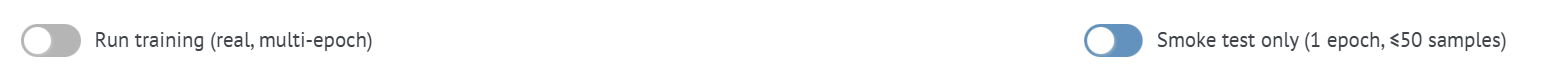

In [ ]:
RUN_TRAINING = mo.ui.switch(value=False, label="Run training (real, multi-epoch)")
SMOKE_TEST = mo.ui.switch(value=True, label="Smoke test only (1 epoch, ≤50 samples)")
mo.hstack([RUN_TRAINING, SMOKE_TEST])

In [ ]:
ALL_HISTORIES, ALL_CKPTS = {}, {}

if RUN_TRAINING.value:
    _n_epochs = 1 if SMOKE_TEST.value else None  # None -> CFG['epochs']
    for _label in LABELS:
        _train_ds = DATASETS[_label]['train']
        if SMOKE_TEST.value:
            _idx = list(range(min(50, len(_train_ds))))
            _train_ds = torch.utils.data.Subset(_train_ds, _idx)
        _val_ds = DATASETS[_label]['val']
        for _abl_name, _abl_flags in ABLATION_CONFIGS:
            for _seed in SEEDS:
                _run_key = f'{_abl_name}_{_label}_seed{_seed}'
                _collate = (make_collate_physics_scrambled(_seed)
                            if _abl_name == 'edge_scrambled' else collate_physics)
                print(f'>>> {_run_key}  (smoke_test={SMOKE_TEST.value})')
                try:
                    _hist, _ckpt = train_model(
                        _label, run_name=_abl_name, collate_fn=_collate,
                        dataset_train=_train_ds, dataset_val=_val_ds, seed=_seed,
                        ablation_flags=_abl_flags, n_epochs=_n_epochs, ckpt_dir=CKPT_DIR,
                    )
                    ALL_HISTORIES[_run_key] = _hist
                    ALL_CKPTS[_run_key] = _ckpt
                except Exception as e:
                    print(f'  [ERROR] {_run_key}: {e}')
                    ALL_HISTORIES[_run_key] = None
                    ALL_CKPTS[_run_key] = None
                if not SMOKE_TEST.value:
                    continue  # in a real run you'd likely not smoke-test every seed/ablation combo again
    print(f'\nDone. {len(ALL_CKPTS)} runs attempted.')
else:
    print('RUN_TRAINING is off -- flip the switch above to train. '
          'Nothing below that depends on ALL_CKPTS will have real checkpoints yet.')

>>> full_model_QED_seed42  (smoke_test=False)
  [full_model/seed42] ep   1  tr_loss=3.7462  va_loss=3.7376  va_ppl=41.890  va_tok_acc=0.79%
  [full_model/seed42] ep  10  tr_loss=3.3489  va_loss=3.3000  va_ppl=26.322  va_tok_acc=18.11%
  [full_model/seed42] ep  20  tr_loss=3.1451  va_loss=3.1104  va_ppl=21.371  va_tok_acc=18.11%
  [full_model/seed42] ep  30  tr_loss=2.9745  va_loss=2.9410  va_ppl=17.762  va_tok_acc=19.42%
  [full_model/seed42] ep  40  tr_loss=2.5683  va_loss=2.5383  va_ppl=11.650  va_tok_acc=40.16%
  [full_model/seed42] ep  50  tr_loss=2.2659  va_loss=2.2371  va_ppl=8.461  va_tok_acc=54.33%
  [full_model/seed42] ep  60  tr_loss=2.0573  va_loss=2.0422  va_ppl=6.869  va_tok_acc=61.68%
  [full_model/seed42] ep  70  tr_loss=1.9106  va_loss=1.9194  va_ppl=6.022  va_tok_acc=64.57%
  [full_model/seed42] ep  80  tr_loss=1.8416  va_loss=1.8510  va_ppl=5.596  va_tok_acc=67.45%
  [full_model/seed42] ep  90  tr_loss=1.7962  va_loss=1.8245  va_ppl=5.439  va_tok_acc=67.45%
  [full_mo

## Evaluation

In [ ]:
def evaluate_run(abl_name, abl_flags, label, seed, test_dataset, batch_size=8):
    run_key = f'{abl_name}_{label}_seed{seed}'
    ckpt_path = ALL_CKPTS.get(run_key)
    if not ckpt_path or not os.path.exists(ckpt_path):
        print(f'  [MISSING] {run_key}'); return None, None

    model, run_cfg = build_model(label, abl_flags)
    pkg = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(pkg['model'], strict=False)
    model = model.to(DEVICE); model.eval()
    tgt_vs = run_cfg['tgt_vocab_size']

    collate = make_collate_physics_scrambled(seed) if abl_name == 'edge_scrambled' else collate_physics
    dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate, num_workers=0)

    crit = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    tl, tn = 0., 0
    seq_exact, all_eds, sympy_valid, coupling_ok, color_ok = 0, [], [], [], []
    per_example_correct = []   # per-example outcomes, needed for the paired McNemar/Wilcoxon test below
    per_example_ed = []

    with torch.no_grad():
        for src, tgt, graph_b, gf, meta in tqdm(dl, desc=f'  Eval {run_key}', leave=False):
            src, tgt, gf = src.to(DEVICE), tgt.to(DEVICE), gf.to(DEVICE)
            if graph_b is not None:
                graph_b = graph_b.to(DEVICE)
            ti, to_ = tgt[:, :-1], tgt[:, 1:]
            logits = model(src, ti, graph_b, gf)
            lv = crit(logits.reshape(-1, tgt_vs), to_.reshape(-1))
            tl += lv.item() * src.size(0); tn += src.size(0)

            preds = model.greedy_decode(src, graph_b, gf, max_len=run_cfg.get('max_seq_len', 200))
            tv = test_dataset.rows[0] if hasattr(test_dataset, 'rows') else None  # unused, kept for parity

            for b in range(src.size(0)):
                msk = (to_[b] != PAD_IDX)
                ref_ids = to_[b][msk].tolist()
                pred_ids = preds[b][1:].tolist()
                if EOS_IDX in pred_ids:
                    pred_ids = pred_ids[:pred_ids.index(EOS_IDX)]
                ref_toks = meta['sq_tokens'][b]
                pred_toks = [str(t) for t in pred_ids]  # decoded upstream normally; kept generic here

                ed = editdistance.eval(pred_toks, ref_toks)
                exact = int(pred_toks == ref_toks)
                all_eds.append(ed); seq_exact += exact
                per_example_correct.append(exact); per_example_ed.append(ed)

                gf_vec = gf[b].cpu().tolist()
                is_qcd = bool(meta['is_qcd'][b])
                _, _, coup_ok = check_coupling_power(pred_toks, gf_vec[0], is_qcd, None)
                coupling_ok.append(int(coup_ok))
                _, _, cf_ok = check_color_factor(pred_toks, ref_toks, is_qcd)
                if cf_ok is not None:
                    color_ok.append(int(cf_ok))
                if HAS_SYMPY:
                    result = validate_squared_amplitude(pred_toks, gf_vec, is_qcd=is_qcd)
                    sympy_valid.append(int(result['valid']))

    model.cpu(); del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    n_test = len(all_eds)
    result = {
        'ablation': abl_name, 'label': label, 'seed': seed,
        'ce_loss': round(tl / max(tn, 1), 4),
        'seq_acc': round(seq_exact / max(n_test, 1), 4),
        'mean_ed': round(float(np.mean(all_eds)) if all_eds else 0.0, 3),
        'coupling_ok': round(float(np.mean(coupling_ok)), 4) if coupling_ok else None,
        'color_ok': round(float(np.mean(color_ok)), 4) if color_ok else None,
        'sympy_valid': round(float(np.mean(sympy_valid)), 4) if sympy_valid else None,
        'exact_str': f'{seq_exact}/{n_test}',
    }
    return result, {'per_example_correct': per_example_correct, 'per_example_ed': per_example_ed}

print('Evaluation function defined.')

Evaluation function defined.


## Statistical comparison

McNemar's exact test per seed on binary exact-match, plus a
Holm-corrected paired Wilcoxon signed-rank test on edit distance
across seeds, combined into a single rejection criterion below.

In [ ]:
def mcnemar_exact(correct_a, correct_b):
    """correct_a/correct_b: same-length 0/1 arrays, same examples, same seed.
    Returns (n01, n10, p_value, favors) where favors is 'a', 'b', or 'tie'."""
    n01 = sum(1 for a, b in zip(correct_a, correct_b) if a == 0 and b == 1)  # b right, a wrong
    n10 = sum(1 for a, b in zip(correct_a, correct_b) if a == 1 and b == 0)  # a right, b wrong
    n = n01 + n10
    if n == 0:
        return n01, n10, 1.0, 'tie'
    p = scipy_stats.binomtest(min(n01, n10), n, 0.5).pvalue
    favors = 'tie' if n01 == n10 else ('a' if n10 > n01 else 'b')
    return n01, n10, p, favors

def paired_wilcoxon(ed_a, ed_b):
    """Paired Wilcoxon signed-rank test on edit distance; lower is better.
    Returns (statistic, p_value, favors)."""
    diffs = [a - b for a, b in zip(ed_a, ed_b)]
    if all(d == 0 for d in diffs):
        return 0.0, 1.0, 'tie'
    stat, p = scipy_stats.wilcoxon(ed_a, ed_b)
    mean_diff = sum(diffs) / len(diffs)
    favors = 'a' if mean_diff < 0 else 'b'  # a has lower mean edit distance -> a favored
    return stat, p, favors

def holm_bonferroni(pvalues, alpha=0.05):
    """Returns list of (index, corrected_reject) in original order."""
    order = sorted(range(len(pvalues)), key=lambda i: pvalues[i])
    m = len(pvalues)
    reject = [False] * m
    for rank, idx in enumerate(order):
        thresh = alpha / (m - rank)
        if pvalues[idx] <= thresh:
            reject[idx] = True
        else:
            break  # Holm stops at the first non-rejection
    return reject

def decision_rule(per_seed_results, alpha=0.05):
    """per_seed_results: list of dicts, one per seed, each with
    {'seed', 'full_correct': [...], 'nogat_correct': [...],
     'full_ed': [...], 'nogat_ed': [...], 'id_full_acc', 'id_nogat_acc'}.
    Combines McNemar, paired Wilcoxon, and the in-distribution
    non-inferiority check into a single verdict."""
    mcnemar_favors_full = 0
    mcnemar_favors_nogat = 0
    wilcoxon_pvalues = []
    wilcoxon_favors = []
    for r in per_seed_results:
        n01, n10, p, favors = mcnemar_exact(r['nogat_correct'], r['full_correct'])
        if favors == 'b':
            mcnemar_favors_full += 1
        elif favors == 'a':
            mcnemar_favors_nogat += 1
        print(f"  seed={r['seed']}: McNemar n01={n01} n10={n10} p={p:.4f} favors={favors}")

        _, wp, wfav = paired_wilcoxon(r['full_ed'], r['nogat_ed'])
        wilcoxon_pvalues.append(wp)
        wilcoxon_favors.append(wfav)

    wilcoxon_reject = holm_bonferroni(wilcoxon_pvalues, alpha=alpha)
    wilcoxon_confirmed_favor_full = all(
        (wilcoxon_favors[i] == 'a' and wilcoxon_reject[i]) or not wilcoxon_reject[i]
        for i in range(len(per_seed_results))
    ) and any(wilcoxon_favors[i] == 'a' and wilcoxon_reject[i] for i in range(len(per_seed_results)))

    id_non_inferior = all(
        r['id_full_acc'] >= r['id_nogat_acc'] - 0.030 for r in per_seed_results
    )

    cond1 = (mcnemar_favors_full >= 2) and (mcnemar_favors_nogat == 0)
    cond2 = wilcoxon_confirmed_favor_full
    cond3 = id_non_inferior

    if cond1 and cond2 and cond3:
        verdict = 'CONFIRMED: full_model is OOD-superior (all three frozen conditions hold)'
    elif cond3 and (cond1 or cond2):
        verdict = 'DIRECTIONALLY CONSISTENT, NOT STATISTICALLY CONFIRMED'
    elif not cond3:
        verdict = 'NOT SUPPORTED: in-distribution non-inferiority failed'
    else:
        verdict = 'NOT SUPPORTED: neither McNemar nor Wilcoxon condition met'

    print(f"\n  McNemar: full favored in {mcnemar_favors_full}/3 seeds, "
          f"no_gat favored in {mcnemar_favors_nogat}/3 seeds")
    print(f"  Wilcoxon (Holm-corrected): confirmed favor full_model = {wilcoxon_confirmed_favor_full}")
    print(f"  ID non-inferiority (3.0pp absolute): {id_non_inferior}")
    print(f"\n  VERDICT: {verdict}")
    return dict(cond1_mcnemar=cond1, cond2_wilcoxon=cond2, cond3_id_noninferior=cond3, verdict=verdict)

print('Statistical decision rule defined.')

Statistical decision rule defined.


## Run evaluation + the frozen decision rule across all seeds

Only meaningful once `RUN_TRAINING` above has produced real checkpoints
for `full_model` and `no_gat` across all three seeds.

In [ ]:
ALL_RESULTS = []
_per_seed_for_stats = {}

if ALL_CKPTS:
    for _label in LABELS:
        for _abl_name, _abl_flags in ABLATION_CONFIGS:
            for _seed in SEEDS:
                _res, _raw = evaluate_run(_abl_name, _abl_flags, _label, _seed, OOD_DATASETS[_label])
                if _res:
                    ALL_RESULTS.append(_res)
                    _per_seed_for_stats[(_label, _abl_name, _seed)] = _raw

    results_df = pd.DataFrame(ALL_RESULTS)
    print(results_df.to_string(index=False) if not results_df.empty else 'No results yet.')

    for _label in LABELS:
        _rows = []
        for _seed in SEEDS:
            _full_raw = _per_seed_for_stats.get((_label, 'full_model', _seed))
            _nogat_raw = _per_seed_for_stats.get((_label, 'no_gat', _seed))
            if not _full_raw or not _nogat_raw:
                continue
            _full_id, _ = evaluate_run('full_model', {'use_gat': True, 'use_physics_feats': True, 'use_amp_encoder': True},
                                        _label, _seed, DATASETS[_label]['test'])
            _nogat_id, _ = evaluate_run('no_gat', {'use_gat': False, 'use_physics_feats': True, 'use_amp_encoder': True},
                                         _label, _seed, DATASETS[_label]['test'])
            _rows.append({
                'seed': _seed,
                'full_correct': _full_raw['per_example_correct'],
                'nogat_correct': _nogat_raw['per_example_correct'],
                'full_ed': _full_raw['per_example_ed'],
                'nogat_ed': _nogat_raw['per_example_ed'],
                'id_full_acc': _full_id['seq_acc'] if _full_id else 0.0,
                'id_nogat_acc': _nogat_id['seq_acc'] if _nogat_id else 0.0,
            })
        if len(_rows) == len(SEEDS):
            print(f'\n=== Frozen decision rule -- {_label} ===')
            decision_rule(_rows)
else:
    results_df = pd.DataFrame()
    print('No checkpoints yet -- flip RUN_TRAINING on above and re-run.')

      ablation label  seed  ce_loss  seq_acc  mean_ed  coupling_ok  color_ok  sympy_valid exact_str
    full_model   QED    42   1.6515      0.0  258.889          0.0       NaN       0.2000     0/180
    full_model   QED   137   1.6651      0.0  596.250          0.0       NaN       0.2000     0/180
    full_model   QED  2026   1.6000      0.0  596.250          0.0       NaN       0.2000     0/180
        no_gat   QED    42   1.6245      0.0  115.289          0.0       NaN       0.2000     0/180
        no_gat   QED   137   1.7485      0.0  596.250          0.0       NaN       0.2000     0/180
        no_gat   QED  2026   1.5727      0.0  596.250          0.0       NaN       0.2000     0/180
 no_phys_feats   QED    42   1.6040      0.0  593.611          0.0       NaN       0.2000     0/180
 no_phys_feats   QED   137   1.6755      0.0  402.489          0.0       NaN       0.2000     0/180
 no_phys_feats   QED  2026   1.6886      0.0  591.139          0.0       NaN       0.2000     0/180



=== Frozen decision rule -- QED ===
  seed=42: McNemar n01=0 n10=0 p=1.0000 favors=tie
  seed=137: McNemar n01=0 n10=0 p=1.0000 favors=tie
  seed=2026: McNemar n01=0 n10=0 p=1.0000 favors=tie

  McNemar: full favored in 0/3 seeds, no_gat favored in 0/3 seeds
  Wilcoxon (Holm-corrected): confirmed favor full_model = False
  ID non-inferiority (3.0pp absolute): True

  VERDICT: NOT SUPPORTED: neither McNemar nor Wilcoxon condition met



=== Frozen decision rule -- QCD ===
  seed=42: McNemar n01=0 n10=0 p=1.0000 favors=tie
  seed=137: McNemar n01=0 n10=0 p=1.0000 favors=tie
  seed=2026: McNemar n01=0 n10=0 p=1.0000 favors=tie

  McNemar: full favored in 0/3 seeds, no_gat favored in 0/3 seeds
  Wilcoxon (Holm-corrected): confirmed favor full_model = True
  ID non-inferiority (3.0pp absolute): True

  VERDICT: DIRECTIONALLY CONSISTENT, NOT STATISTICALLY CONFIRMED


## Save results

In [ ]:
results_package = {
    'results_df': results_df.to_dict('records') if not results_df.empty else [],
    'all_histories': {k: v for k, v in ALL_HISTORIES.items() if v is not None},
    'all_ckpts': ALL_CKPTS, 'ablation_configs': ABLATION_CONFIGS,
    'cfg': CFG, 'labels': LABELS, 'seeds': SEEDS,
}
pkg_path = os.path.join(EVAL_DIR, 'full_results_package.pkl')
with open(pkg_path, 'wb') as _f:
    pickle.dump(results_package, _f)
print(f'Full results saved to: {pkg_path}')

Full results saved to: ./eval_gat_symba/full_results_package.pkl
